# 03: Okada Forward Model (Single Fault)

## Learning objectives
- Use `okada85.py` as a forward model for surface displacement.
- Plot fault outline on a map using simple geometry.
- Plot horizontal displacement vectors and vertical filled-circle data.

**Important:** `okada85.py` is a tested implementation and should not be modified.

In [1]:
%load_ext autoreload
%autoreload 2
from okada_utils import fault_outline, build_patch_grid, build_component_greens

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import okada85

plt.rcParams['figure.figsize'] = (7, 5)
plt.rcParams['axes.grid'] = True

In [2]:
def plot_fault_patches(ax, polygons, slips=None, cmap='viridis', vmin=None, vmax=None):
    """
    Plot fault patch outlines. If slips is provided, fill by colormap.
    """
    if slips is None:
        for poly in polygons:
            ax.plot(poly[:, 0] / 1000.0, poly[:, 1] / 1000.0, color='k', linewidth=1.5)
        return None

    slips = np.asarray(slips)
    if vmin is None:
        vmin = float(np.min(slips))
    if vmax is None:
        vmax = float(np.max(slips))
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    mapper = cm.ScalarMappable(norm=norm, cmap=cmap)

    for poly, s in zip(polygons, slips):
        color = mapper.to_rgba(float(s))
        ax.fill(poly[:, 0] / 1000.0, poly[:, 1] / 1000.0, color=color, alpha=0.9, edgecolor='k', linewidth=1.0)

    return mapper


def plot_data_on_map(ax, obs_e, obs_n, uE, uN, uU, quiver_step=3, quiver_scale=0.02, title=''):
    """
    Plot data as horizontal vectors + vertical filled circles.
    """
    n_side = int(np.sqrt(len(obs_e)))
    E = obs_e.reshape(n_side, n_side)
    N = obs_n.reshape(n_side, n_side)
    UE = uE.reshape(n_side, n_side)
    UN = uN.reshape(n_side, n_side)

    # Horizontal vectors
    ax.quiver(
        E[::quiver_step, ::quiver_step] / 1000.0,
        N[::quiver_step, ::quiver_step] / 1000.0,
        UE[::quiver_step, ::quiver_step],
        UN[::quiver_step, ::quiver_step],
        color='k',
        scale=quiver_scale,
        width=0.003,
    )

    # Vertical rates/displacements as filled circles
    sc = ax.scatter(obs_e / 1000.0, obs_n / 1000.0, c=uU, s=28, cmap='RdBu_r', edgecolor='k', linewidth=0.3)

    ax.set_xlabel('East (km)')
    ax.set_ylabel('North (km)')
    ax.set_aspect('equal')
    ax.set_title(title)
    return sc

In [3]:
# Observation grid (local EN in meters)
x = np.linspace(-40000, 40000, 41)
y = np.linspace(-40000, 40000, 41)
E, N = np.meshgrid(x, y)

obs_e = E.ravel()
obs_n = N.ravel()

# Single-fault parameters
depth = 5000.0
strike = 320.0
dip = 20.0
L = 30000.0
W = 15000.0

rake = 90.0
slip = 1.0
opening = 0.0
nu = 0.25

# Forward model displacement
uE, uN, uU = okada85.displacement(
    obs_e, obs_n, depth, strike, dip, L, W, rake, slip, opening, nu
)

# Fault polygon for map plotting
poly = fault_outline(depth, dip, L, W, strike, centroid_E_m=0.0, centroid_N_m=0.0)

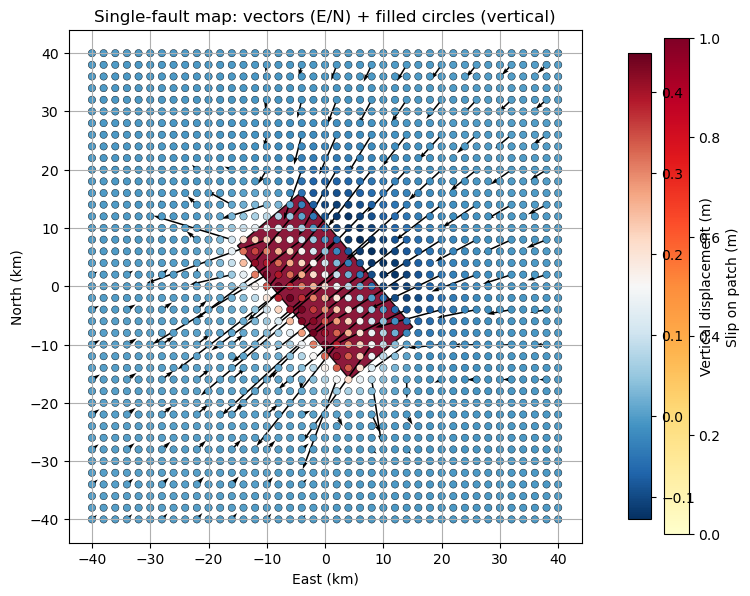

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))

# One patch, one slip value (single-fault model)
mapper = plot_fault_patches(ax, [poly], slips=[slip], cmap='YlOrRd', vmin=0.0, vmax=max(1.0, slip))

sc = plot_data_on_map(
    ax, obs_e, obs_n, uE, uN, uU,
    quiver_step=3,
    quiver_scale=1,
    title='Single-fault map: vectors (E/N) + filled circles (vertical)'
)

cbar1 = plt.colorbar(mapper, ax=ax, fraction=0.04, pad=0.02)
cbar1.set_label('Slip on patch (m)')

cbar2 = plt.colorbar(sc, ax=ax, fraction=0.04, pad=0.08)
cbar2.set_label('Vertical displacement (m)')

plt.show()

## Exercise (TODO)
1. Change `strike`, `dip`, and `rake`; describe how vectors and vertical signal change.
2. Move fault centroid and compare near-field patterns.
3. Increase depth and compare amplitude decay.

## Summary
- You plotted a fault outline from geometry parameters.
- You plotted vectors for horizontal displacement and filled circles for vertical displacement.
- This visualization style will carry into multi-patch inversion notebooks.